In [18]:
# Roll No: 24BAD047

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score

In [19]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\4_sem\ML\EX_NO_6\churn_boosting.csv")

In [20]:
df.columns = df.columns.str.strip()

In [21]:
target_col = None
for col in df.columns:
    if col.lower() == "churn":
        target_col = col
        break

if target_col is None:
    raise Exception("Churn column not found!")

In [22]:
df[target_col] = df[target_col].astype(str).str.strip().str.lower()

In [23]:
df = df[df[target_col].notna()]

In [24]:
X = pd.get_dummies(df.drop(target_col, axis=1))
y = df[target_col]

In [25]:
print("Class Distribution:\n", y.value_counts())

Class Distribution:
 Churn
0    113
1      7
Name: count, dtype: int64


In [26]:
if len(y.unique()) < 2:
    raise Exception("Dataset has only one class. Cannot proceed!")


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()

In [29]:
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [30]:
ada_prob = ada.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

In [31]:
y_test = y_test.astype(int)
fpr1, tpr1, _ = roc_curve(y_test, ada_prob)
fpr2, tpr2, _ = roc_curve(y_test, gb_prob)

In [32]:
ada_auc = roc_auc_score(y_test, ada_prob)
gb_auc = roc_auc_score(y_test, gb_prob)

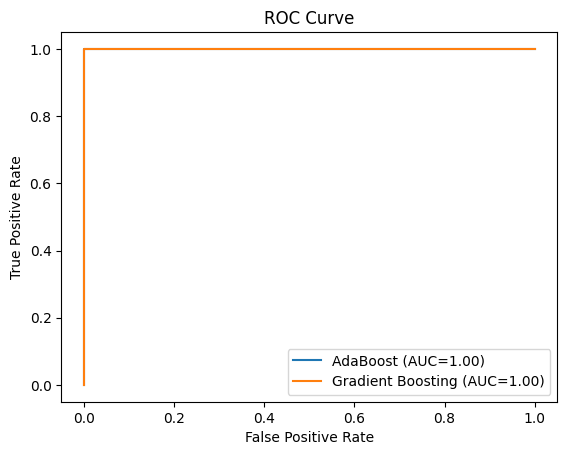

In [33]:
plt.figure()
plt.plot(fpr1, tpr1, label=f"AdaBoost (AUC={ada_auc:.2f})")
plt.plot(fpr2, tpr2, label=f"Gradient Boosting (AUC={gb_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

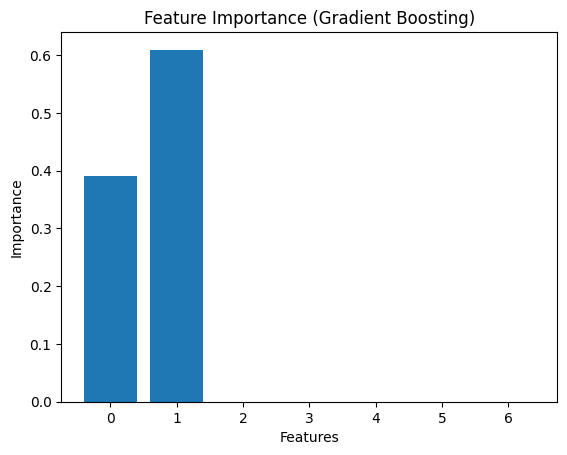

In [34]:
plt.figure()
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()